In [5]:
# Assingment-08
# Q1.Assingment No. 01

In [6]:
import pandas as pd

In [7]:
import numpy as np

In [9]:
import matplotlib.pyplot as plt

In [10]:
from sklearn.cluster import KMeans

In [25]:
from sklearn.cluster import KMeans

In [20]:
# Task-01 
# Create 50–100 records manually in CSV format.

In [21]:
# Task-02
# Load the dataset using pandas.

In [13]:
df = pd.read_csv('Student_performance.csv')
df

,Study_Hours,Attendance_Percentage,Assignment_Score
0,1.0,55,40
1,1.5,60,42
2,2.0,58,45
3,1.2,50,38
4,1.8,62,44
...,...,...,...
71,7.5,90,87
72,8.0,93,91
73,7.2,88,85
74,7.8,92,89


In [14]:
df.head()

,Study_Hours,Attendance_Percentage,Assignment_Score
0,1.0,55,40
1,1.5,60,42
2,2.0,58,45
3,1.2,50,38
4,1.8,62,44


In [15]:
df.tail()

,Study_Hours,Attendance_Percentage,Assignment_Score
71,7.5,90,87
72,8.0,93,91
73,7.2,88,85
74,7.8,92,89
75,8.5,96,94


In [16]:
df.info

<bound method DataFrame.info of     Study_Hours  Attendance_Percentage  Assignment_Score
0           1.0                     55                40
1           1.5                     60                42
2           2.0                     58                45
3           1.2                     50                38
4           1.8                     62                44
..          ...                    ...               ...
71          7.5                     90                87
72          8.0                     93                91
73          7.2                     88                85
74          7.8                     92                89
75          8.5                     96                94

[76 rows x 3 columns]>

In [17]:
df.describe

<bound method NDFrame.describe of     Study_Hours  Attendance_Percentage  Assignment_Score
0           1.0                     55                40
1           1.5                     60                42
2           2.0                     58                45
3           1.2                     50                38
4           1.8                     62                44
..          ...                    ...               ...
71          7.5                     90                87
72          8.0                     93                91
73          7.2                     88                85
74          7.8                     92                89
75          8.5                     96                94

[76 rows x 3 columns]>

In [18]:
df.isnull().sum()

Study_Hours              0
Attendance_Percentage    0
Assignment_Score         0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

In [22]:
# Task-03
# Select features for clustering.

In [23]:
features = ["Study_Hours", "Attendance_Percentage", "Assignment_Score"]
X = df[features]
print("Task 3: Selected Features")
print(X.head())
print()

Task 3: Selected Features
   Study_Hours  Attendance_Percentage  Assignment_Score
0          1.0                     55                40
1          1.5                     60                42
2          2.0                     58                45
3          1.2                     50                38
4          1.8                     62                44



In [24]:
# Task-04
# Train a K-Means Clustering model (n_clusters=3).

In [32]:
model = KMeans(
    n_clusters=3,
    random_state=42
)
model.fit(X)

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [29]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)
print("Task 4: KMeans model trained with n_clusters=3")

Task 4: KMeans model trained with n_clusters=3


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [33]:
# Task-05
# Predict cluster labels.

In [38]:
clusters = model.predict(X)
df['cluster'] = clusters
df.head()

,Study_Hours,Attendance_Percentage,Assignment_Score,cluster,Cluster
0,1.0,55,40,2,2
1,1.5,60,42,2,2
2,2.0,58,45,2,2
3,1.2,50,38,2,2
4,1.8,62,44,2,2


In [39]:
df["Cluster"] = kmeans.predict(X)
print("Task 5: Cluster Labels Predicted")
print(df.head(10))

Task 5: Cluster Labels Predicted
   Study_Hours  Attendance_Percentage  Assignment_Score  cluster  Cluster
0          1.0                     55                40        2        2
1          1.5                     60                42        2        2
2          2.0                     58                45        2        2
3          1.2                     50                38        2        2
4          1.8                     62                44        2        2
5          2.2                     65                48        2        2
6          1.0                     52                41        2        2
7          1.6                     59                43        2        2
8          2.5                     68                50        2        2
9          1.3                     54                39        2        2


In [40]:
# Task=06
# Display cluster centers.

In [41]:
centers = pd.DataFrame(kmeans.cluster_centers_, columns=features)
print("Task 6: Cluster Centers")
print(centers)

Task 6: Cluster Centers
   Study_Hours  Attendance_Percentage  Assignment_Score
0     4.496154              77.153846         67.038462
1     7.780000              91.320000         89.000000
2     1.732000              59.720000         44.280000


In [42]:
# Task-07
# Visualize clusters using a scatter plot.

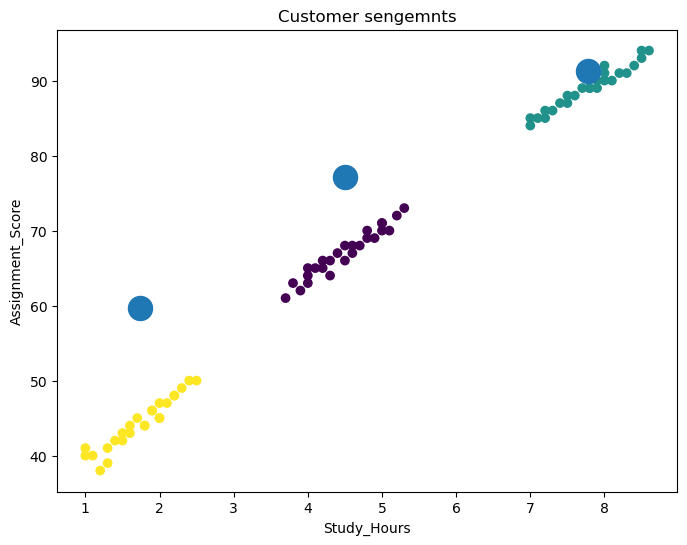

In [45]:
plt.figure(figsize=(8,6))
plt.scatter(
    X['Study_Hours'],
    X['Assignment_Score'],
    c = df['cluster']
)
plt.scatter(
    model.cluster_centers_[:,0],
    model.cluster_centers_[0:,1],
    s=300
)
plt.xlabel("Study_Hours"),
plt.ylabel("Assignment_Score")
plt.title("Customer sengemnts")
plt.show()

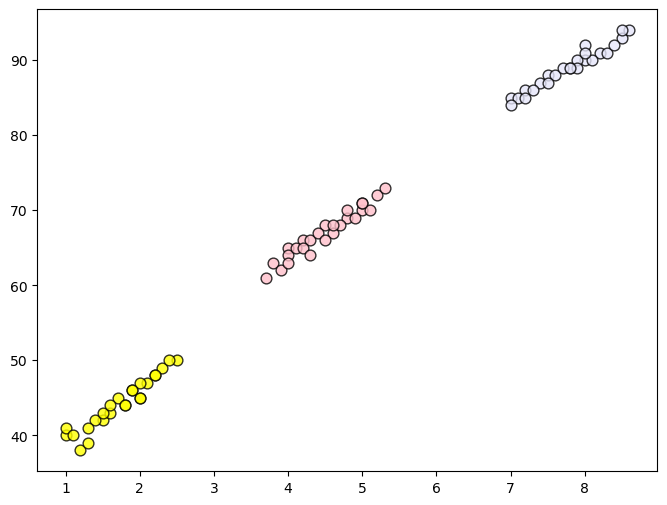

In [44]:
plt.figure(figsize=(8, 6))
colors = ["pink", "lavender", "yellow"]
 
for cluster_id in sorted(df["Cluster"].unique()):
    cluster_data = df[df["Cluster"] == cluster_id]
    plt.scatter(
        cluster_data["Study_Hours"],
        cluster_data["Assignment_Score"],
        s=60,
        c=colors[cluster_id],
        label=f"Cluster {cluster_id}",
        edgecolors="k",
        alpha=0.8,
    )

Text(0.5, 1.0, 'Student Performance Clusters (K-Means, k=3)')

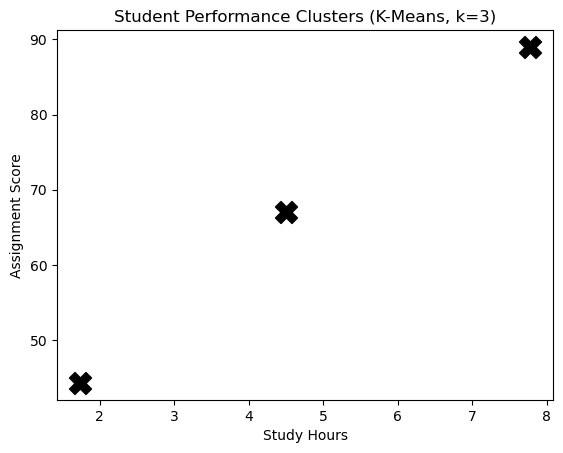

In [48]:
plt.scatter(
    centers["Study_Hours"],
    centers["Assignment_Score"],
    s=250,
    c="black",
    marker="X",
    label="Centroids",
)
 
plt.xlabel("Study Hours")
plt.ylabel("Assignment Score")
plt.title("Student Performance Clusters (K-Means, k=3)")